In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv("grocery_chain_data.csv")
print(data)

      customer_id          store_name transaction_date           aisle  \
0            2824   GreenGrocer Plaza       26-08-2023         Produce   
1            5506    ValuePlus Market       13-02-2024           Dairy   
2            4657    ValuePlus Market       23-11-2023          Bakery   
3            2679   SuperSave Central       13-01-2025  Snacks & Candy   
4            9935   GreenGrocer Plaza       13-10-2023    Canned Goods   
...           ...                 ...              ...             ...   
1975         1699      Corner Grocery       30-07-2024    Frozen Foods   
1976         1829    City Fresh Store       15-12-2023   Personal Care   
1977         8096   MegaMart Westside       06-05-2025           Dairy   
1978         7471    QuickStop Market       26-08-2024    Frozen Foods   
1979         1483  FamilyFood Express       30-05-2024    Canned Goods   

      product_name  quantity  unit_price  total_amount  discount_amount  \
0            Pasta         2        

In [42]:
data.isnull().sum()

customer_id          0
store_name          25
transaction_date     0
aisle                0
product_name         0
quantity             0
unit_price           0
total_amount         0
discount_amount      0
final_amount         0
loyalty_points       0
dtype: int64

In [3]:
print(data["customer_id"].duplicated().sum())

182


In [4]:
df = data.drop_duplicates('customer_id')
print(df) 

      customer_id          store_name transaction_date           aisle  \
0            2824   GreenGrocer Plaza       26-08-2023         Produce   
1            5506    ValuePlus Market       13-02-2024           Dairy   
2            4657    ValuePlus Market       23-11-2023          Bakery   
3            2679   SuperSave Central       13-01-2025  Snacks & Candy   
4            9935   GreenGrocer Plaza       13-10-2023    Canned Goods   
...           ...                 ...              ...             ...   
1973         3110   SuperSave Central       17-10-2023          Bakery   
1975         1699      Corner Grocery       30-07-2024    Frozen Foods   
1977         8096   MegaMart Westside       06-05-2025           Dairy   
1978         7471    QuickStop Market       26-08-2024    Frozen Foods   
1979         1483  FamilyFood Express       30-05-2024    Canned Goods   

      product_name  quantity  unit_price  total_amount  discount_amount  \
0            Pasta         2        

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1980 non-null   int64  
 1   store_name        1955 non-null   str    
 2   transaction_date  1980 non-null   str    
 3   aisle             1980 non-null   str    
 4   product_name      1980 non-null   str    
 5   quantity          1980 non-null   int64  
 6   unit_price        1980 non-null   float64
 7   total_amount      1980 non-null   float64
 8   discount_amount   1980 non-null   float64
 9   final_amount      1980 non-null   float64
 10  loyalty_points    1980 non-null   int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 170.3 KB


In [6]:
df.describe()

,customer_id,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
count,1798.000000,1798.000000,1798.000000,1798.000000,1798.000000,1798.000000,1798.000000
mean,5528.617909,2.968854,15.491496,45.964605,4.414227,41.550378,255.476085
std,2580.419399,1.414264,8.353732,34.916415,4.942738,32.504818,146.767921
min,1006.000000,1.000000,0.990000,1.010000,0.000000,-3.430000,0.000000
25%,3274.250000,2.000000,8.350000,17.922500,1.202500,15.800000,127.000000
50%,5559.000000,3.000000,15.210000,37.415000,2.980000,33.375000,266.000000
75%,7795.250000,4.000000,22.740000,68.347500,5.200000,61.067500,380.000000
max,9998.000000,5.000000,29.980000,149.900000,29.940000,147.910000,500.000000


In [7]:
df.isnull().sum()

customer_id          0
store_name          19
transaction_date     0
aisle                0
product_name         0
quantity             0
unit_price           0
total_amount         0
discount_amount      0
final_amount         0
loyalty_points       0
dtype: int64

In [60]:
total_revenue = df['total_amount'].sum()
print(total_revenue)

82644.35999999999


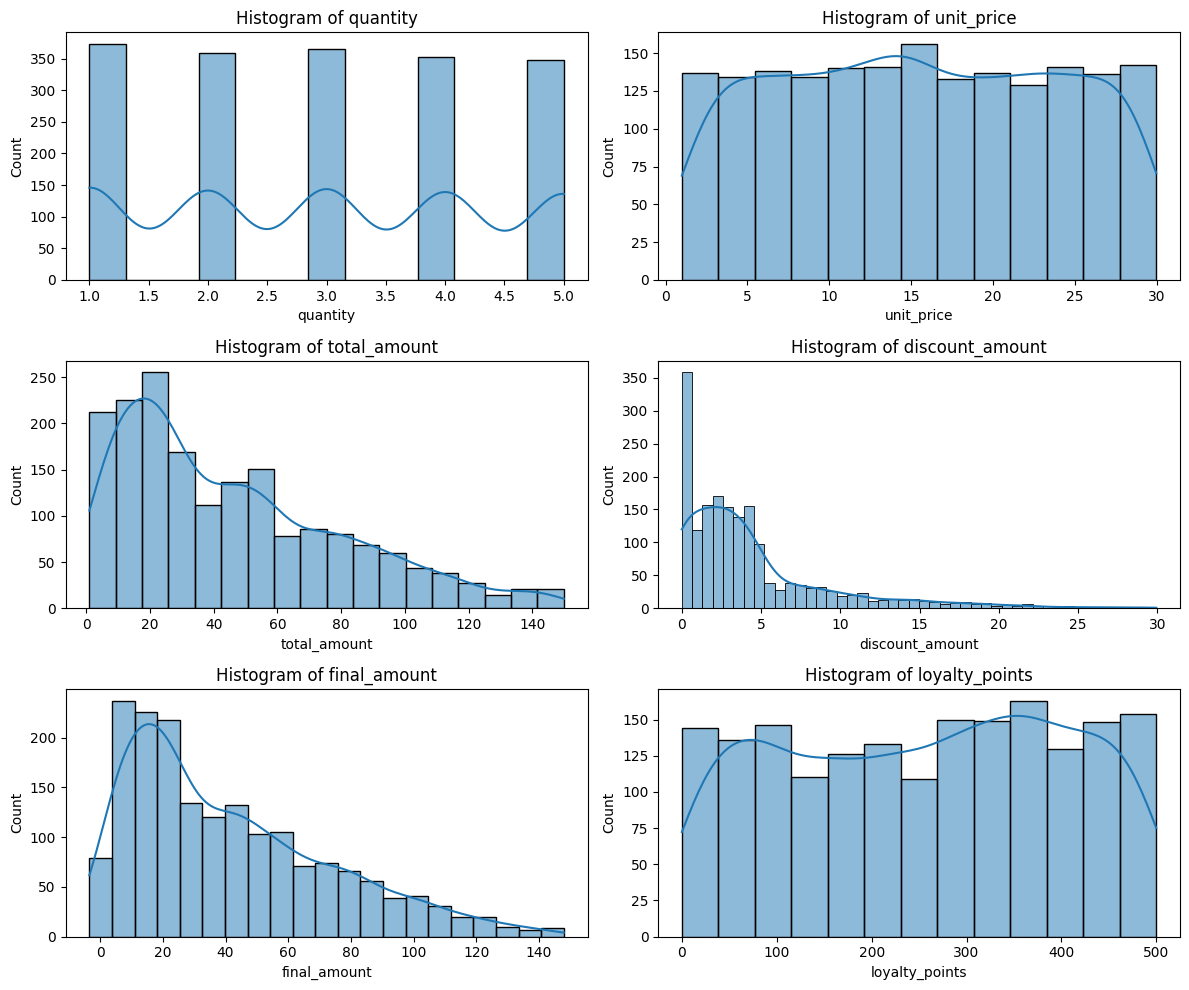

In [28]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(['quantity', 'unit_price', 'total_amount', 'discount_amount', 'final_amount', 'loyalty_points']):
    plt.subplot(3, 2, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

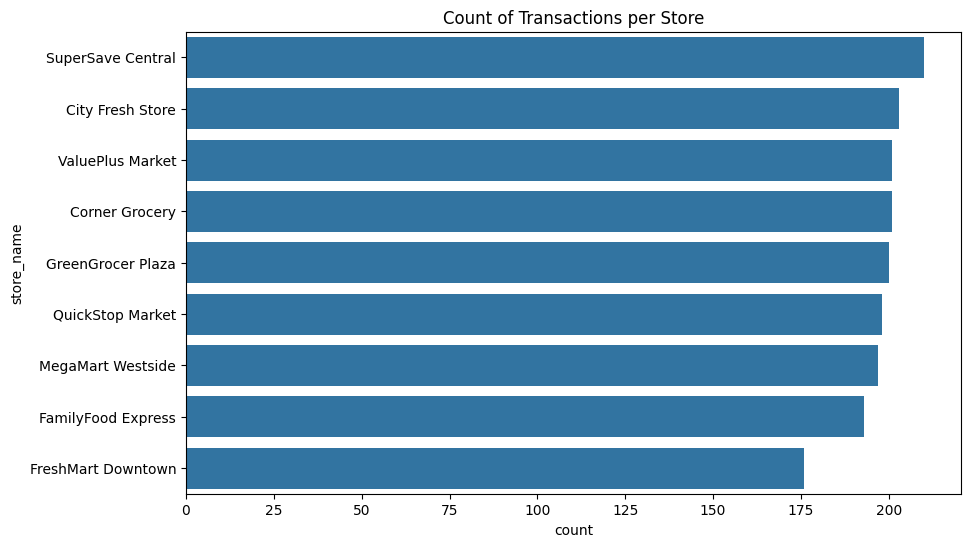

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(y='store_name', data=df, order=df['store_name'].value_counts().index)
plt.title('Count of Transactions per Store')
plt.show()

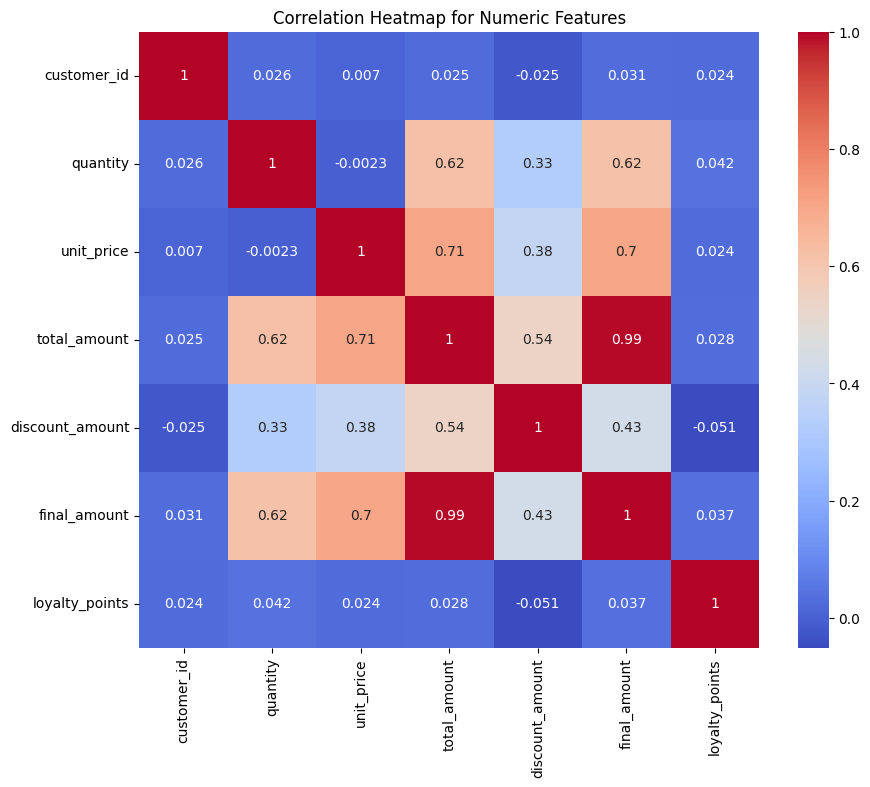

In [34]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for Numeric Features')
plt.show()

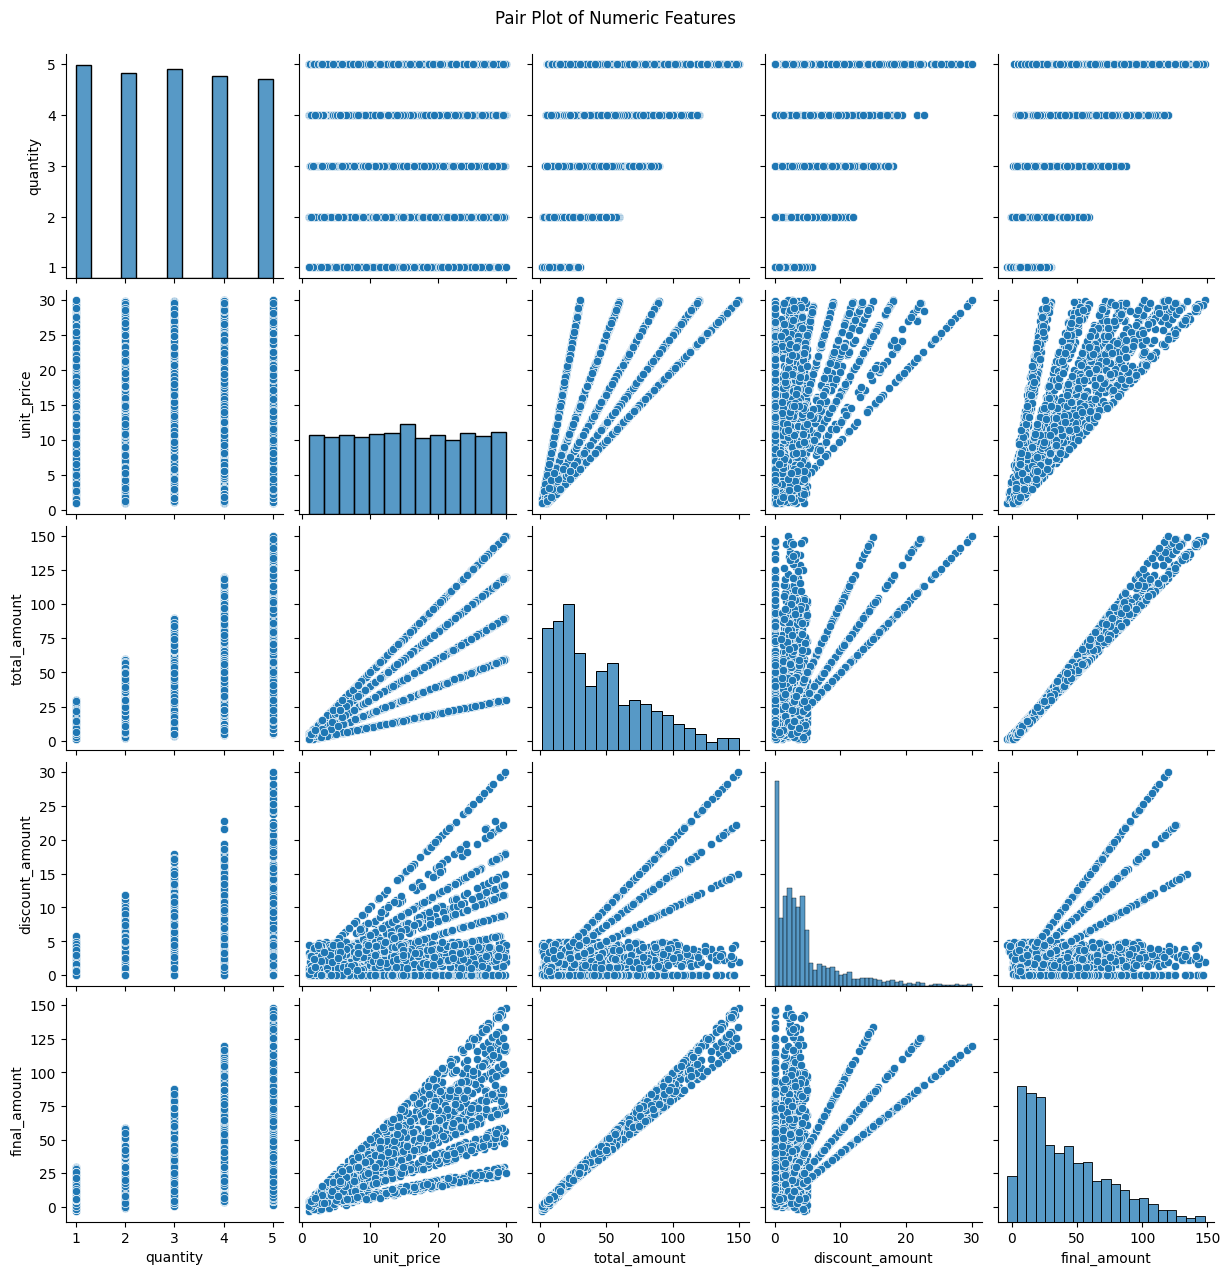

In [35]:
sns.pairplot(df[['quantity', 'unit_price', 'total_amount', 'discount_amount', 'final_amount']])
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

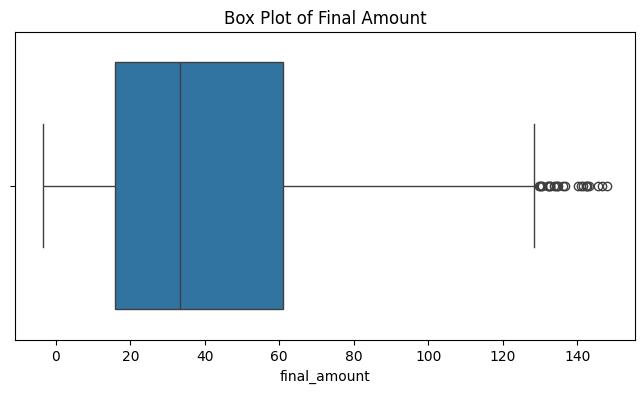

In [36]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['final_amount'])
plt.title('Box Plot of Final Amount')
plt.show()